# 05 · Supplier Scorecard
Turn the quote-level data into one row per supplier scored 0–100 on five **configurable** weighted dimensions, then assign a category and a recommended action.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40, "display.width", 160)
from src import config as C
print("project root:", ROOT)

project root: D:\proyectos\porsche intership\Price Intelligence\automotive-procurement-price-intelligence


In [2]:
from src import supplier_scoring as ss
df = pd.read_csv(C.PROCESSED_QUOTES_CSV)
print('weights:', C.SCORECARD_WEIGHTS)
sc = ss.score_suppliers(df)
sc[['supplier_name','country','final_supplier_score','supplier_category','recommended_action']].head(10)

weights: {'cost_competitiveness': 0.3, 'delivery_reliability': 0.25, 'quality_performance': 0.2, 'risk_exposure': 0.15, 'sustainability': 0.1}
Out[2]: 
                supplier_name         country  final_supplier_score       supplier_category                 recommended_action
0  Meridian Components s.r.o.  Czech Republic                  85.9       Strategic Partner  Prioritize for long-term contract
1      Drava Electronics S.A.           Spain                  85.3       Strategic Partner  Prioritize for long-term contract
2       Larix Castings s.r.o.  Czech Republic                  83.2       Strategic Partner  Prioritize for long-term contract
3    Westmark Industries GmbH         Germany                  82.2       Strategic Partner  Prioritize for long-term contract
4      Pallas Mobility s.r.o.  Czech Republic                  81.9  Reliable but Expensive                  Renegotiate price
5         Orion Mobility S.A.           Spain                  81.6       Strategic Pa

,supplier_name,country,final_supplier_score,supplier_category,recommended_action
0,Meridian Components s.r.o.,Czech Republic,85.9,Strategic Partner,Prioritize for long-term contract
1,Drava Electronics S.A.,Spain,85.3,Strategic Partner,Prioritize for long-term contract
2,Larix Castings s.r.o.,Czech Republic,83.2,Strategic Partner,Prioritize for long-term contract
3,Westmark Industries GmbH,Germany,82.2,Strategic Partner,Prioritize for long-term contract
4,Pallas Mobility s.r.o.,Czech Republic,81.9,Reliable but Expensive,Renegotiate price
5,Orion Mobility S.A.,Spain,81.6,Strategic Partner,Prioritize for long-term contract
6,Ibex Mobility GmbH,Germany,81.2,Strategic Partner,Prioritize for long-term contract
7,Magna Castings S.p.A.,Italy,80.8,Strategic Partner,Prioritize for long-term contract
8,Quanta Mobility GmbH,Germany,78.8,Strategic Partner,Prioritize for long-term contract
9,Caldera Drivetrain s.r.o.,Czech Republic,78.1,Reliable but Expensive,Renegotiate price


## Category & action distribution

In [3]:
display(sc.supplier_category.value_counts().to_frame('suppliers'))
display(sc.recommended_action.value_counts().to_frame('suppliers'))

,suppliers
supplier_category,
Cost Efficient,17
Reliable but Expensive,16
High Risk,11
Strategic Partner,10
Needs Improvement,6


,suppliers
recommended_action,
Reduce dependency,14
Renegotiate price,13
Develop as strategic partner,12
Prioritize for long-term contract,10
Monitor quality risk,6
Keep as backup supplier,5


## Scorecard profile by category

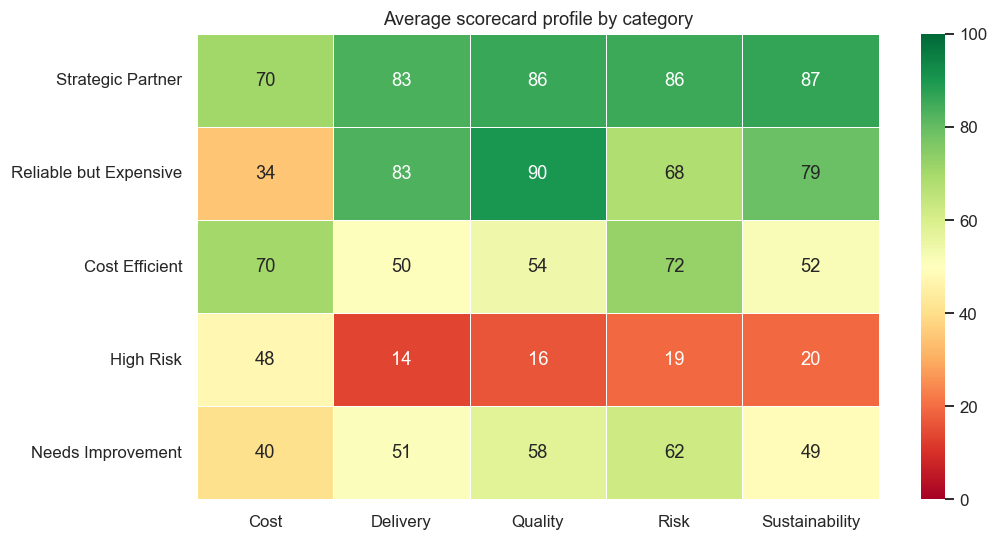

In [4]:
dims = {'cost_competitiveness_score':'Cost','delivery_reliability_score':'Delivery',
        'quality_performance_score':'Quality','risk_exposure_score':'Risk','sustainability_score_norm':'Sustainability'}
order=[c for c in ['Strategic Partner','Reliable but Expensive','Cost Efficient','High Risk','Needs Improvement'] if c in sc.supplier_category.unique()]
mat = sc.groupby('supplier_category')[list(dims)].mean().reindex(order).rename(columns=dims)
fig, ax = plt.subplots(figsize=(10,5.5))
sns.heatmap(mat, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100, linewidths=.5, ax=ax)
ax.set_title('Average scorecard profile by category'); ax.set_ylabel(''); plt.show()

## Validation — does the scorecard rediscover the latent archetypes?
The generating archetype is hidden ground truth (it would not exist in real data).

In [5]:
master = pd.read_csv(C.SUPPLIER_MASTER_CSV)[['supplier_id','archetype']]
j = sc.merge(master, on='supplier_id')
pd.crosstab(j.archetype, j.supplier_category)

Out[5]: 
supplier_category       Cost Efficient  High Risk  Needs Improvement  Reliable but Expensive  Strategic Partner
archetype                                                                                                      
Balanced                             2          0                  1                       3                  0
Cost Efficient                       9          2                  2                       0                  1
High Risk                            1          9                  0                       0                  0
Reliable but Expensive               0          0                  0                       6                  0
Strategic Partner                    0          0                  0                       7                  9
Underperformer                       5          0                  3                       0                  0


supplier_category,Cost Efficient,High Risk,Needs Improvement,Reliable but Expensive,Strategic Partner
archetype,,,,,
Balanced,2,0,1,3,0
Cost Efficient,9,2,2,0,1
High Risk,1,9,0,0,0
Reliable but Expensive,0,0,0,6,0
Strategic Partner,0,0,0,7,9
Underperformer,5,0,3,0,0


## Top and bottom suppliers

In [6]:
cols=['supplier_name','country','final_supplier_score','supplier_category','recommended_action']
print('TOP 5'); display(sc.nlargest(5,'final_supplier_score')[cols])
print('BOTTOM 5'); display(sc.nsmallest(5,'final_supplier_score')[cols])

TOP 5
BOTTOM 5


,supplier_name,country,final_supplier_score,supplier_category,recommended_action
0,Meridian Components s.r.o.,Czech Republic,85.9,Strategic Partner,Prioritize for long-term contract
1,Drava Electronics S.A.,Spain,85.3,Strategic Partner,Prioritize for long-term contract
2,Larix Castings s.r.o.,Czech Republic,83.2,Strategic Partner,Prioritize for long-term contract
3,Westmark Industries GmbH,Germany,82.2,Strategic Partner,Prioritize for long-term contract
4,Pallas Mobility s.r.o.,Czech Republic,81.9,Reliable but Expensive,Renegotiate price


,supplier_name,country,final_supplier_score,supplier_category,recommended_action
59,"Fenix Systems Co., Ltd.",China,1.0,High Risk,Reduce dependency
58,"Granta Components Co., Ltd.",China,9.2,High Risk,Reduce dependency
57,"Mercura Mobility Co., Ltd.",China,15.2,High Risk,Reduce dependency
56,"Xenon Systems Co., Ltd.",China,15.4,High Risk,Reduce dependency
55,"Atlas Tech Co., Ltd.",China,15.5,High Risk,Reduce dependency


**Business decision.** Prioritize the strategic partners, renegotiate with the premium suppliers that hold the largest spend share, and reduce dependency on the high-risk, high-spend vendors concentrated in a single region.